## Script to plot the MCMC result and provide a template for other plots in the paper
By Andrea

In [ ]:
using Plots
using Plots.Measures

In [20]:
default(fontfamily="Computer Modern", titlefontsize=19, guidefontsize=10, tickfontsize=16, legendfontsize=12)


### Packages to read MCMC file

In [13]:
using Serialization

In [3]:
true_mu = 0.0
true_sigma = 0.0

0.0

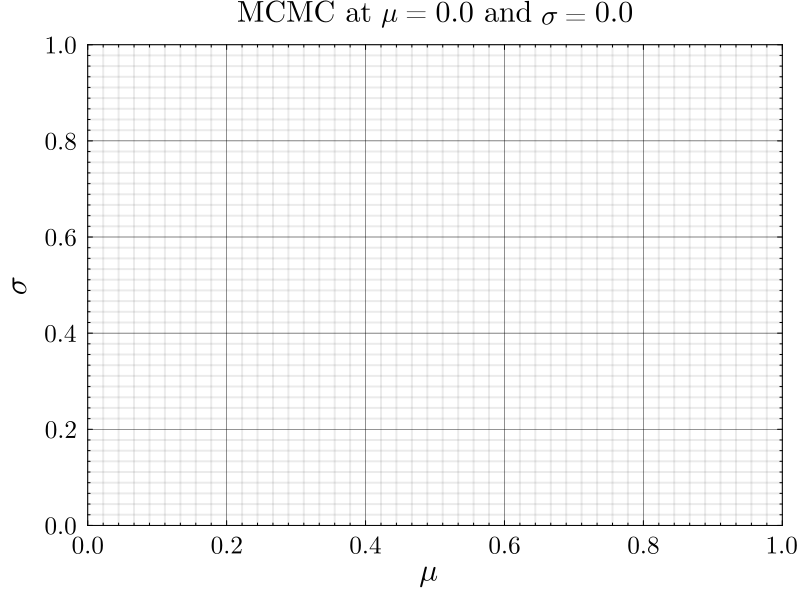

In [ ]:
# TEMPLETE Plot

MCMC_plot=plot(xlabel="\$\\mu\$ ", ylabel="\$\\sigma\$", title="MCMC at \$\\mu=\$$true_mu and \$\\sigma=\$$true_sigma",
  legend=:topright,  minorticks=9, minorgrid=true, grid=true, minorgridwidth=2.,
 minorgridalpha=.04, gridwidth=0.5, gridalpha=0.5,
  labelfontsize=21, size=(800, 600), left_margin = 2mm, bottom_margin = 2mm, right_margin = 2.5mm, top_margin = 2.5mm,
  framestyle=:box,
    ylim = (0.,Inf))


### Matteo template

In [ ]:
import Statistics: mean, std  # Explicitly import only the required functions
using Plots
using LaTeXStrings  # Proper LaTeX font support

# Use LaTeX-like fonts
default(fontfamily="Computer Modern", titlefontsize=12, guidefontsize=10, tickfontsize=8, legendfontsize=9)

# Proper LaTeX labels
xlabel_str = L"\mathrm{PN~Order}"  # Use \mathrm for proper LaTeX rendering
ylabel_str = L"\mathrm{Cumulative~Error}"

# Define a list of different markers to enhance readability
markers = [:circle, :square, :diamond, :utriangle, :dtriangle, :hexagon]

# Calculate mean and standard deviation for each ii and jj
mean_cumulative_error = zeros(length(PNorder_), length(name_network))
std_cumulative_error = zeros(length(PNorder_), length(name_network))

for ii in 1:length(PNorder_)
    for jj in 1:length(name_network)
        mean_cumulative_error[ii, jj] = mean(cumulative_split_error[:, ii, jj])
        std_cumulative_error[ii, jj] = std(cumulative_split_error[:, ii, jj])
    end
end

plot_padding_top= 10;
plot_padding_bottom = 3;

# Find the minimum and maximum values for y-axis limits, excluding the first point
min_y = minimum(mean_cumulative_error[2:end, :]) / plot_padding_bottom  # Divide by 10 for some padding
max_y = maximum(mean_cumulative_error[2:end, :]) * plot_padding_top  # Multiply by 10 for some padding

# Find the minimum and maximum values for y-axis limits, excluding the first point
min_y_sub = minimum([mean_cumulative_error[1], LVK_GWTC3_results[1]]) / plot_padding_bottom  # Divide by 10 for some padding
max_y_sub = maximum([mean_cumulative_error[1], LVK_GWTC3_results[1]]) * plot_padding_top  # Multiply by 10 for some padding

# Initialize the main plot with white background and high resolution
cc_main = plot(
    xlabel=xlabel_str, title="Cumulative Error on PN Order - PhenomD LVK default",
    legend=:bottomright, xticks=(2:10, name_PN[2:end]), 
    yscale=:log10, size=(900, 600), dpi=300,
    xlims=(1.5, 10.5),
    grid=true, framestyle=:box,
    yticks=[10.0^i for i in floor(Int, log10(min_y)):ceil(Int, log10(max_y))],  # Set y-axis ticks for each 10^N value within the range
    ylims=(min_y, max_y),  # Automatically set the y-axis range
    gridalpha=0.5, gridcolor=:gray,  # Set grid lines to be transparent or gray
    yminorgrid=true, minorgridalpha=0.3, minorgridcolor=:gray,  # Enable minor grid lines
    xminorgrid=false  # Disable minor grid lines for the x-axis
)

# Initialize the subplot for the first point
cc_sub = plot(
    xlabel=xlabel_str, ylabel=ylabel_str,
    legend=false, xticks=([1], [name_PN[1]]), 
    xlims=(0.5, 1.5),
    yscale=:log10, size=(300, 600), dpi=300,
    grid=true, framestyle=:box,
    yticks=[10.0^i for i in floor(Int, log10(min_y_sub)) : ceil(Int, log10(max_y_sub))],  # Set y-axis ticks for the first point
    ylims=(min_y_sub, max_y_sub),  # Automatically set the y-axis range
    gridalpha=0.5, gridcolor=:gray,  # Set grid lines to be transparent or gray
    yminorgrid=true, minorgridalpha=0.3, minorgridcolor=:gray,  # Enable minor grid lines
    xminorgrid=false  # Disable minor grid lines for the x-axis
)

# Plot the first point in the subplot
for jj in 1:length(name_network)
    scatter!(
        cc_sub, [1], [mean_cumulative_error[1, jj]],
        yerr=[std_cumulative_error[1, jj]],  # Add error bars
        label=name_network[jj],
        marker=markers[mod1(jj, length(markers))],  # Cycle through marker list
        markersize=6, markerstrokewidth=1, markerstrokecolor=:black,
        alpha=0.9  # Slight transparency for overlapping points
    )
end

# Plot the remaining points in the main plot
for jj in 1:length(name_network)
    scatter!(
        cc_main, 2:length(PNorder_), mean_cumulative_error[2:end, jj],
        yerr=std_cumulative_error[2:end, jj],  # Add error bars
        label=name_network[jj] * " forecast",
        marker=markers[mod1(jj, length(markers))],  # Cycle through marker list
        markersize=6, markerstrokewidth=1, markerstrokecolor=:black,
        alpha=0.9  # Slight transparency for overlapping points
    )
    
    # Plot individual errors as small transparent orange horizontal stripes
    for ii in 1:1
        vecc = PN_errors[ii, jj, 1:NUMBER_OF_EVENTS_TO_BE_USED_SINGLE_CATALOG]
        scatter!(
            cc_sub, fill(ii, length(vecc)), vecc,
            marker=:hline, markersize=15, markerstrokewidth=2, alpha=0.5, color=:orange, label=""
        )
    end

    for ii in 2:length(PNorder_)
        vecc = PN_errors[ii, jj, 1:NUMBER_OF_EVENTS_TO_BE_USED_SINGLE_CATALOG]
        scatter!(
            cc_main, fill(ii, length(vecc)), vecc,
            marker=:hline, markersize=15, markerstrokewidth=2, alpha=0.5, color=:orange, label=""
        )
    end
end

# Add a dummy plot for the legend entry in the main plot
scatter!(
    cc_main, [NaN], [NaN],
    marker=:hline, markersize=15, markerstrokewidth=2, alpha=0.5, color=:orange, label="Errors from single events"
)

# Plot the GWTC-3 results in the main plot
scatter!(
    cc_main, 2:length(PNorder_), LVK_GWTC3_results[2:end],
    label="LVK GWTC-3", marker=:diamond, markersize=6, markerstrokewidth=1, markerstrokecolor=:black, color=:darkblue
)

# Plot the first GWTC-3 result in the subplot
scatter!(
    cc_sub, [1], [LVK_GWTC3_results[1]],
    label="LVK GWTC-3", marker=:diamond, markersize=6, markerstrokewidth=1, markerstrokecolor=:black, color=:darkblue
)

# Combine the main plot and the subplot
plot(cc_sub, cc_main, layout = @layout [a{0.15w} b{0.85w}])

# Save the combined plot to a file on the remote server
savefig(plot_path_prefix * "cumulative_PN_error_plot_PhenomD_single_errors_LVK_GWTC3_overlaid.png")

# Display the final plot
display(plot(cc_sub, cc_main, layout = @layout [a{0.15w} b{0.85w}]))

In [12]:
function plot_2d_contour(x, y, true_mu, true_sigma, MCMC_plot)

    # Estimate the kernel density
    xy = [x y]
    kde_result = kde(xy)

    # Extract the density values
    Z = kde_result.density
    X = kde_result.x
    Y = kde_result.y

    # Find the contour levels corresponding to 1σ, 2σ, and 3σ
    sorted_Z = sort(Z[:], rev=true)
    cumsum_Z = cumsum(sorted_Z) / sum(sorted_Z)  # Cumulative sum to get percentiles
    #levels = [0.682, 0.954, 0.997]  # 1σ, 2σ, 3σ intervals
    levels = [0.39, 0.86, 0.99]

    # Find density values corresponding to these probability levels
    sigma_levels = [sorted_Z[findfirst(cumsum_Z .>= level)] for level in levels]

    # Plot contour
    contour!(MCMC_plot, X, Y, Z', levels=sigma_levels, color=:viridis, linewidth=2, label="σ levels")
    #scatter!(x, y, alpha=0.3, label="Samples")
    scatter!(MCMC_plot, [true_mu], [true_sigma], label="True values")
    return MCMC_plot
end

plot_2d_contour (generic function with 1 method)

In [ ]:
function read_chain(file_name)
    chain = deserialize(file_name)
    return chain
end

read_chain (generic function with 1 method)

In [15]:
pn_order_dic = Dict(
    "-1"       => (-1.0    ,"minus_one"),
    "0"        => (0.0     ,"zero"), 
    "0.5"      => (0.5     ,"half"),
    "1"        => (1.0     ,"one"), 
    "1.5"      => (1.5     ,"one_half"),
    "2"        => (2.0     ,"two"),
    "log(2.5)" => (log(2.5),"log_two_half"),
    "3"        => (3.0     ,"three"), 
    "log(3.)"  => (log(3.) ,"log_three"),
    "3.5"      => (3.5     ,"three_half")
);

In [ ]:
# pn_orders =  ["0"]
# pno = pn_orders[1]
#path = "../../gwbeast/output/BGR/data/"network*"/pn_" * pn_order_dic[pno][2]

